## **FEATURE EXTRACTION**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import scipy.signal
import soundfile as sf
from tqdm import tqdm
from scipy.signal import butter, filtfilt, correlate
import scipy.stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from typing import Union, Tuple
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif, mutual_info_classif
import yaml
import re
from collections import Counter
from collections import defaultdict

Load parameters and other configuration values.

In [3]:
# Load audio processing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 60 ms for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 64 Mel Banks to extract the Log-Mel Spectrograms
F_HI = config["audio_processing"]["f_hi"] # Boundary frequency for VLTP is set to 2 kHz
TARGET_DURATION = config["audio_processing"]["target_duration"] # Fix the duration of each cycle to 8 s

FRAME_SIZE = int(FRAME_LENGTH*SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH*SAMPLING_RATE) #  Calculate the amount of samples per hop

# Load basic paths from config.yaml
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])
CLEANED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["cleaned_cycle_folder"])
TRAINING_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["training_set_folder"])
TEST_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["test_set_folder"])

# Feature names 
FEATURE_NAMES = (
    [f"MFCC_{i}" for i in range(N_MFCC)] +
    ["Spectral Centroid", "Spectral Bandwidth", "Zero Crossing Rate", "RMS Energy",
     "Spectral Rolloff", "Spectral Flux", "Spectral Flatness"] 
    + [f"Log_Mel_{i}" for i in range(N_MELS)] + ["On Set Envelope"]
)

# Number of features used
N_FEATURES = len(FEATURE_NAMES) 

In [4]:
# Load training and test sets
train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "raw_training_set.csv"))
final_train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "training_set.csv"))
augmented_labels_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "augmented_training_set.csv"))
test_df = pd.read_csv(os.path.join(TEST_SET_FOLDER, "test_set.csv"))

For both training and testing set we extract **13 MFCCs, 20 Log-Mel, temporal and spectral features** from the final respiratory cycles and create a **feature tensor of size (cycles,frames, features)** for each one of them. Also the **frame length of each cycle is set to 60 ms** with an **overlap of 50%**. These values perform well in terms of low frequency respiratory sounds. For the STFT that is calculated on the features we apply **Hann Window** to smoothen the data leakage. In total **100 frames are used for each respiratory cycle**. Also, the features are extracted across the whole .wav file so that no significant information is omitted.

After the feature tensor is created, we reshape it into a 2D array using 2 methods: either **aggregate over frames using mean( )** and have an array of shape **(cycles, features)** or **flatten the tensor** into an array of shape **(cycles, frames x features)**. The first method produces the final input features that work better for the statistical models and the second helps locate better if there exists domain shift by projecting the temporal signature of each device.

In [ ]:
from utils.audio_preprocessing import extract_acoustic_features, classify

augmented_labels_dict = dict(zip(augmented_labels_df["file"], augmented_labels_df["class"]))

sets = {
    "training": final_train_df,
    "test": test_df
}

# Extract the features from both training and testing set
for split_name, df_subset in sets.items():
    features = []
    labels = []
    filenames = []
    cycles = []

    for fname in tqdm(df_subset["file"], desc=f"Extracting features for {split_name} set"):
        path = os.path.join(CLEANED_CYCLE_FOLDER, fname)
        if not os.path.exists(path):
            print(f"Missing file: {fname}")
            continue

        y, sr = librosa.load(path, sr=SAMPLING_RATE)

        # Extract frame-level features for each respiratory cycle
        feats = extract_acoustic_features(
            y, sr,
            frame_size=FRAME_SIZE,
            hop_size=HOP_SIZE,
            n_mfcc=N_MFCC,
            n_mels=N_MELS
        )  # shape: (frames, features)

        features.append(feats)

        if fname.startswith("AUG_"):
            label = augmented_labels_dict.get(fname)
            if label is None:
                print(f"Warning: No label found for {fname}")
                continue
        else:
            original_file_base = "_".join(fname.split("_")[:-1])
            match = re.search(r"_cycle(\d+)", fname)
            if match:
                cycle_num = int(match.group(1))
            else:
                print(f"Warning: No cycle info in {fname}")
                continue

            annotation_path = os.path.join(AUDIO_FOLDER, original_file_base + ".txt")
            if not os.path.exists(annotation_path):
                print(f"Missing annotation: {annotation_path}")
                continue

            annotations = np.loadtxt(annotation_path)
            if cycle_num >= annotations.shape[0]:
                print(f"Invalid cycle index for {fname}")
                continue

            crackle = int(annotations[cycle_num, 2])
            wheeze = int(annotations[cycle_num, 3])
            label = classify(crackle, wheeze)

        labels.append(label)
        filenames.append(fname)
        cycles.append(cycle_num)

    features = np.stack(features)  
    labels = np.array(labels)
    filenames = np.array(filenames)
    cycles = np.array(cycles)

    # Aggregate the features by computing frame-wise mean over frames 
    features_mean = features.mean(axis=1)  # array shape: (cycles, features)

    # Flatten the features for the entire cycle
    features_flattened = features.reshape(features.shape[0], -1)  # (cycles, frames x features)

    # Convert into arrays and store in .npy files for faster handling
    np.save(f"{split_name}_features.npy", features) # (cycles, frames, features)
    np.save(f"{split_name}_features_mean.npy", features_mean) # (cycles, features)
    np.save(f"{split_name}_features_flattened.npy", features_flattened) # (cycles, frames x features)
    np.save(f"{split_name}_labels.npy", labels) # (cycles, )
    np.save(f"{split_name}_filenames.npy", filenames) # (cycles, )
    np.save(f"{split_name}_cycles.npy", cycles) # (cycles, )

Extracting features for training set:   0%|          | 0/8739 [00:00<?, ?it/s]

Extracting features for test set: 100%|██████████| 1279/1279 [00:22<00:00, 57.19it/s]


In [7]:
# Check if the training and test feature tensors array are in correct shape 
training_features = np.load("training_features.npy")
test_features = np.load("test_features.npy")
print("Training feature tensor shape:", training_features.shape)
print("Test feature tensor shape:", test_features.shape)

Training feature tensor shape: (8739, 101, 41)
Test feature tensor shape: (1279, 101, 41)


In [9]:
# Check if the training and test feature tensors array are in correct shape after aggregation over mean per frame
training_features_mean = np.load("training_features_mean.npy")
test_features_mean = np.load("test_features_mean.npy")
print("Training feature array shape after aggregation over mean:", training_features_mean.shape)
print("Test feature array shape after aggregation over mean:", test_features_mean.shape)

Training feature array shape after aggregation over mean: (8739, 41)
Test feature array shape after aggregation over mean: (1279, 41)


In [8]:
# Check if the training and test feature tensors array are in correct shape after flattening 
training_features_flattened = np.load("training_features_flattened.npy")
test_features_flattened = np.load("test_features_flattened.npy")
print("Training feature array shape after flattening:", training_features_flattened.shape)
print("Training feature array shape after flattening:", test_features_flattened.shape)

Training feature array shape after flattening: (8739, 4141)
Training feature array shape after flattening: (1279, 4141)


### **FEATURE SELECTION**

On the training data we visualize the temporal behavior and discriminative power of a specific audio feature across respiratory cycles. Firstly, we **plot how the feature evolves over time for individual cycles, colored by class**. Secondly, we **plot the average per-frame feature values for each class**, highlighting potential separability. Thirdly, we **display the statistical significance (F-value and -log10(p-value))** of the feature at each frame, indicating when it best differentiates between classes.

### **Aggregation over mean feature exploration**

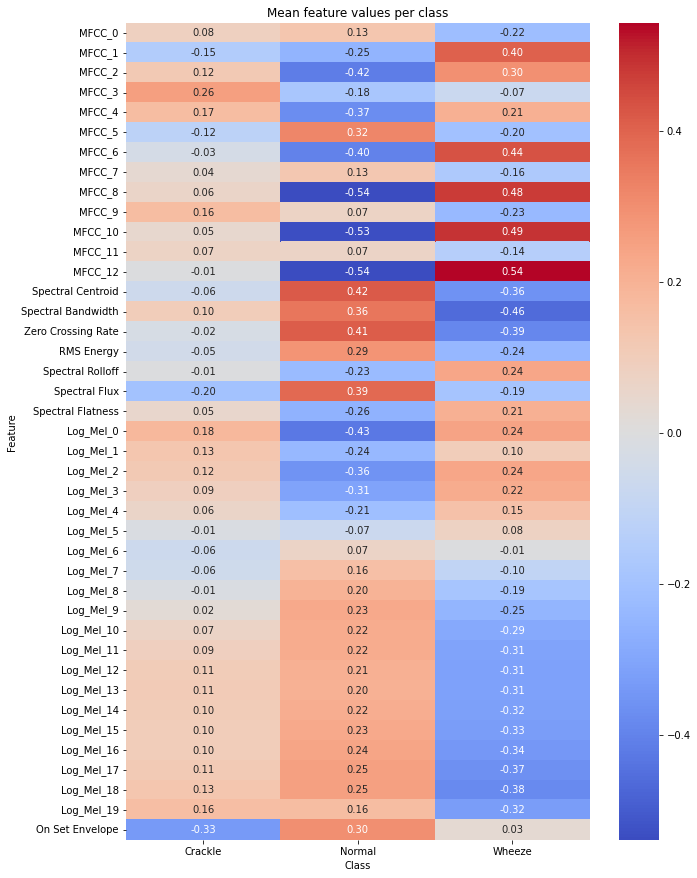

In [7]:
from utils.plots import plot_feature_vs_class_heatmap

# Load the different classes from training set
training_labels = np.load("training_labels.npy")

# Scale the feature values to better visualize if they indeed contribute differently into the class separation
training_features_scaled = StandardScaler().fit_transform(training_features_mean)
training_features_scaled = pd.DataFrame(training_features_scaled, columns=FEATURE_NAMES)

plot_feature_vs_class_heatmap(training_features_scaled, training_labels, feature_names=FEATURE_NAMES)

Then, plot correlation heatmap between features

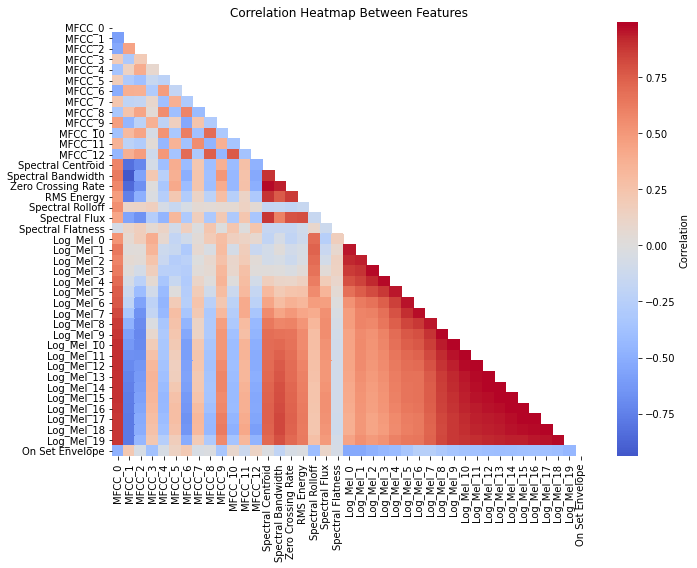

In [8]:
from utils.plots import plot_feature_correlation_heatmap

plot_feature_correlation_heatmap(training_features_scaled, FEATURE_NAMES)

Also, plot KDE graphs and boxplots to visualize the feature distributions

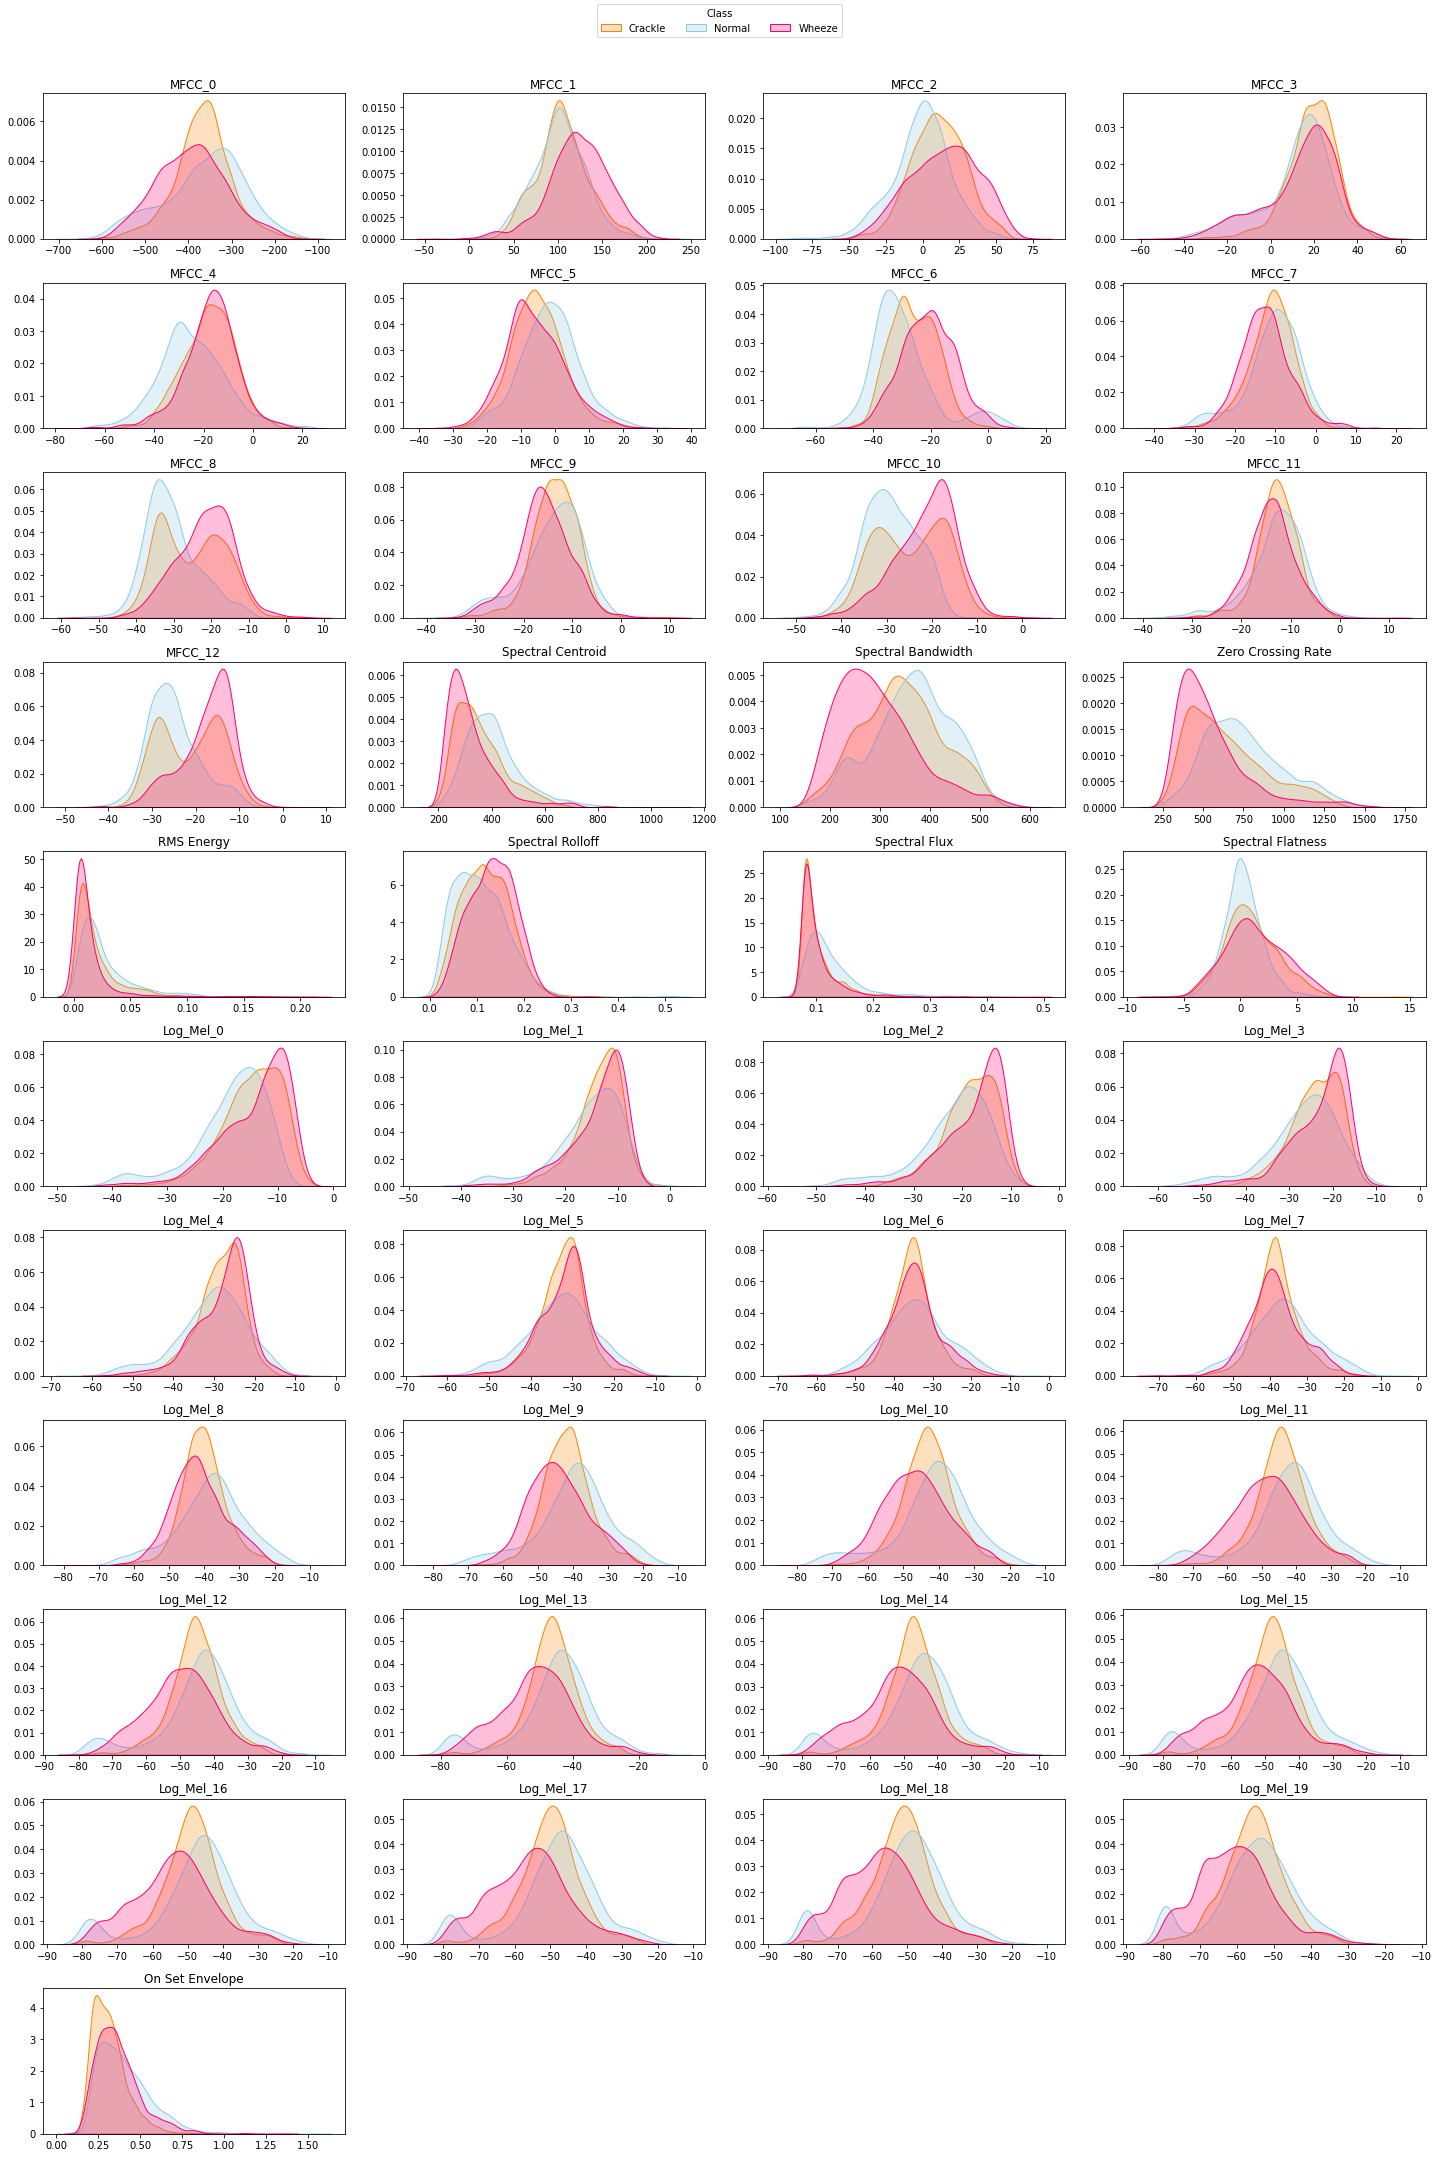

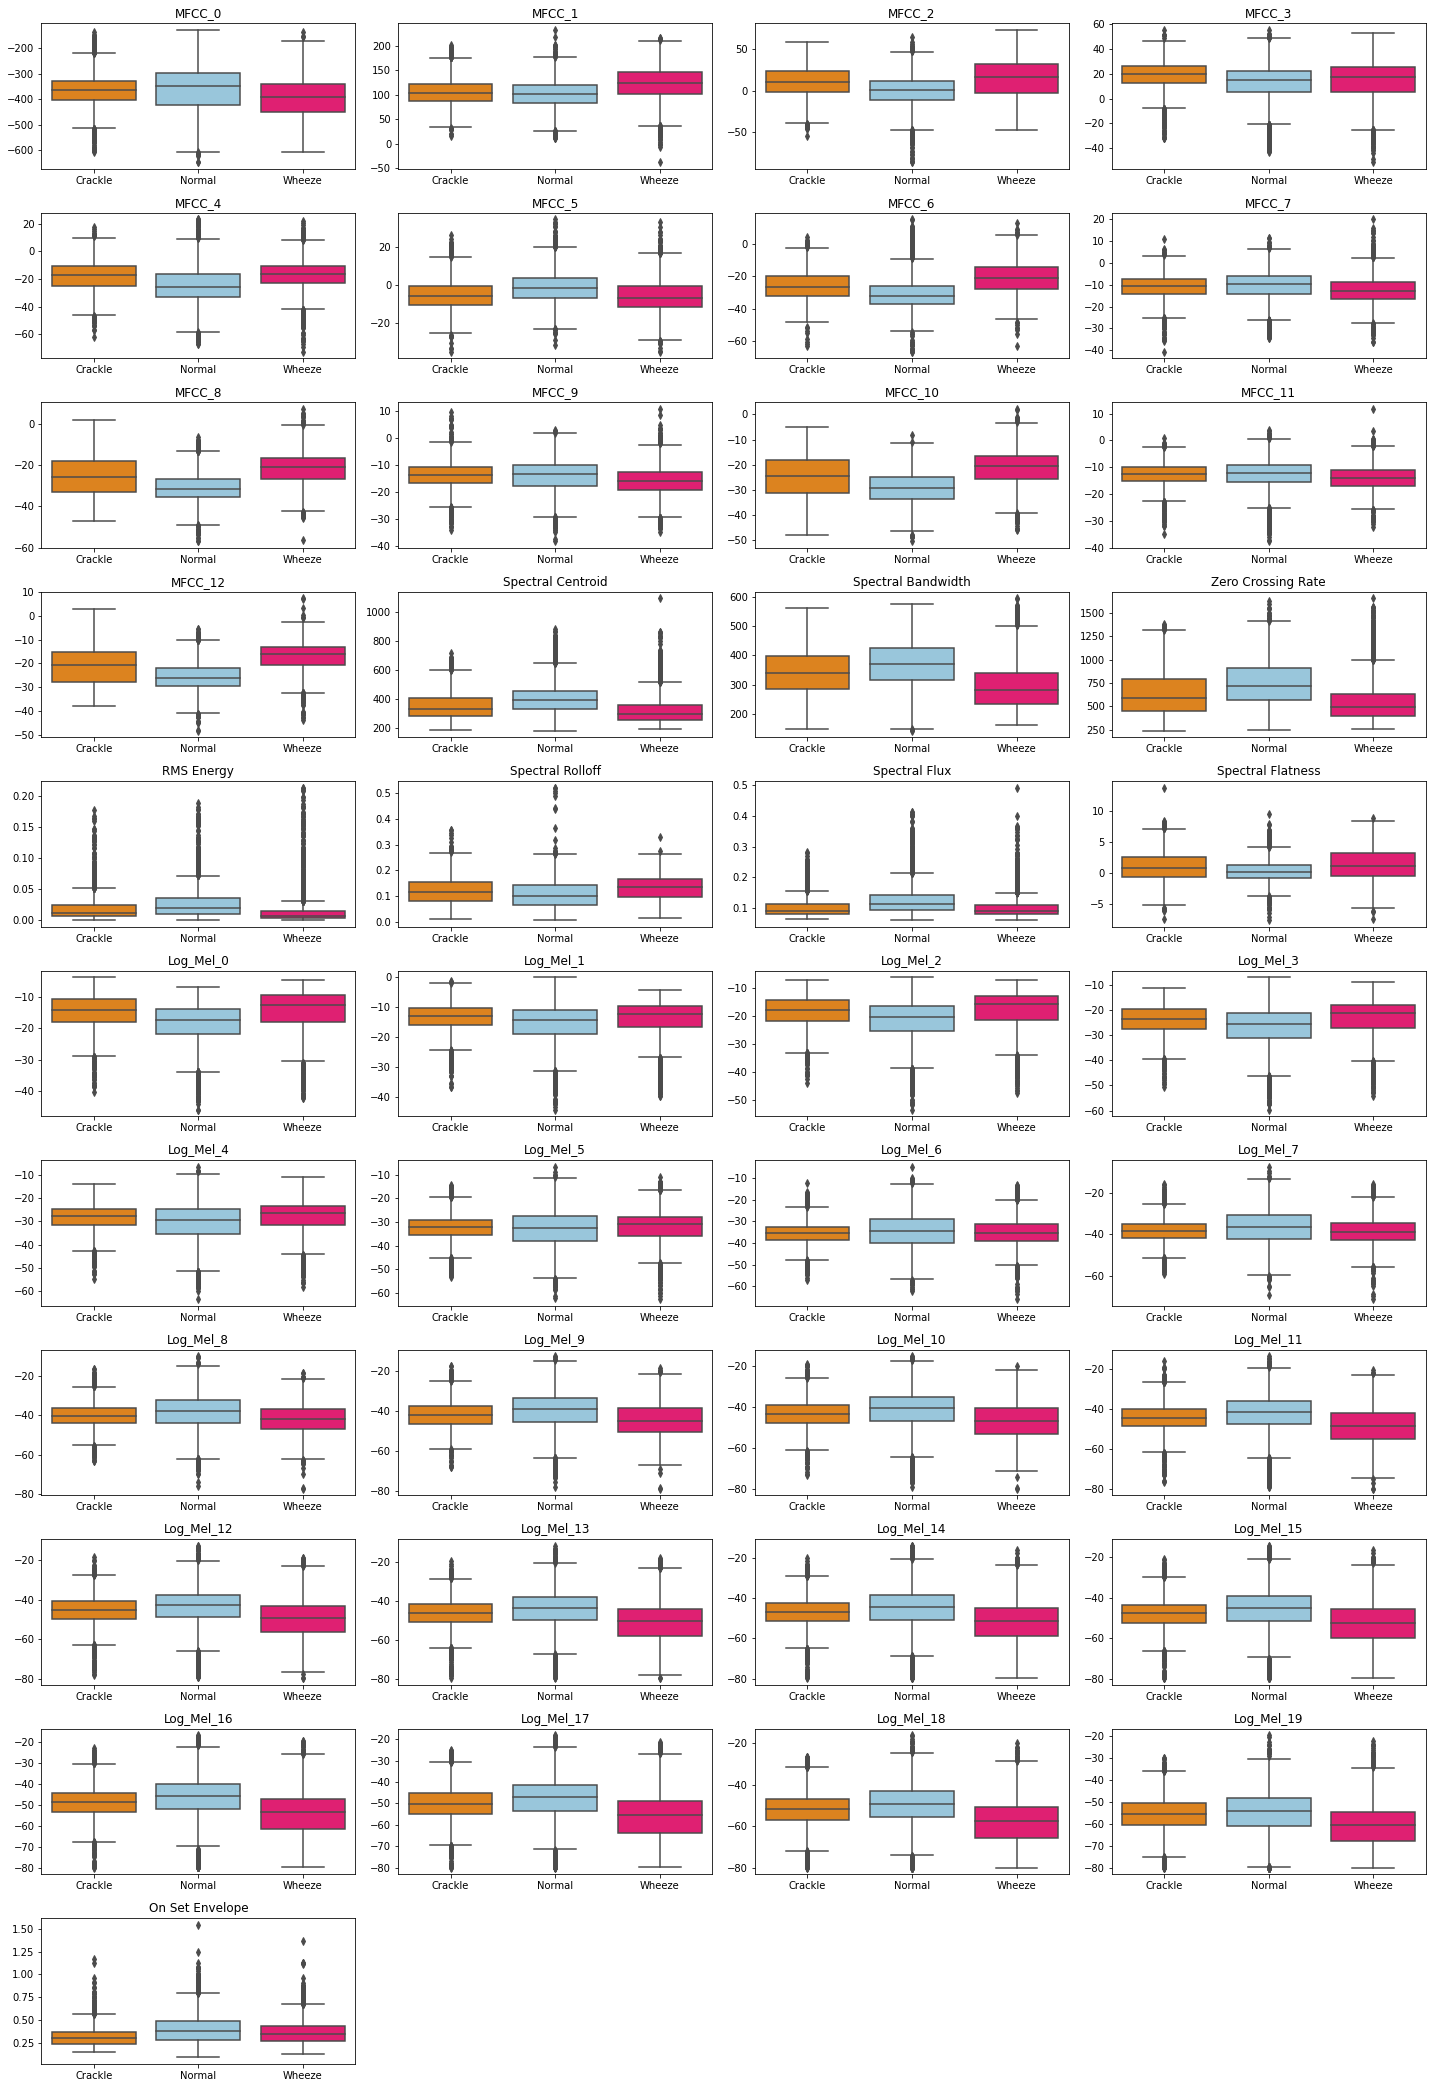

In [9]:
from utils.plots import plot_feature_distributions

plot_feature_distributions(training_features_mean, training_labels, FEATURE_NAMES)

Finally, perform ANOVA Test and visualize F-Score, p-value for every feature

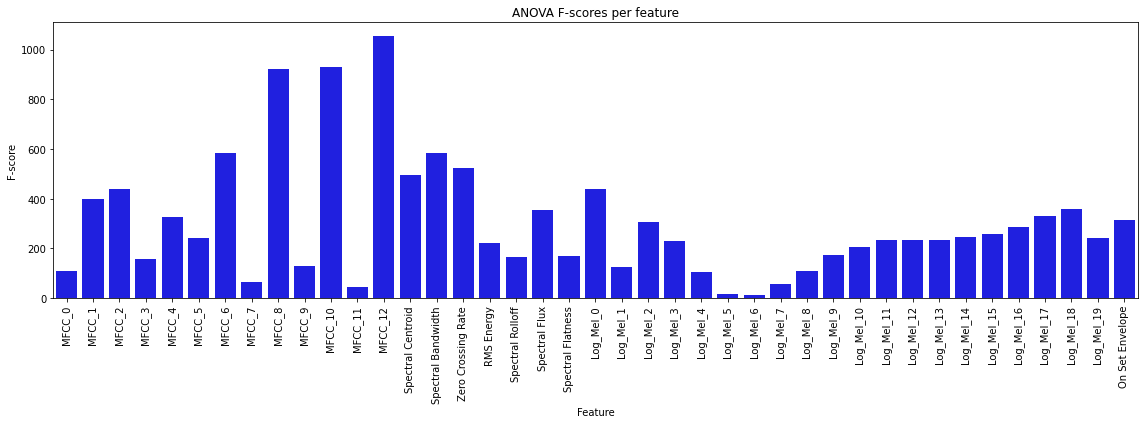

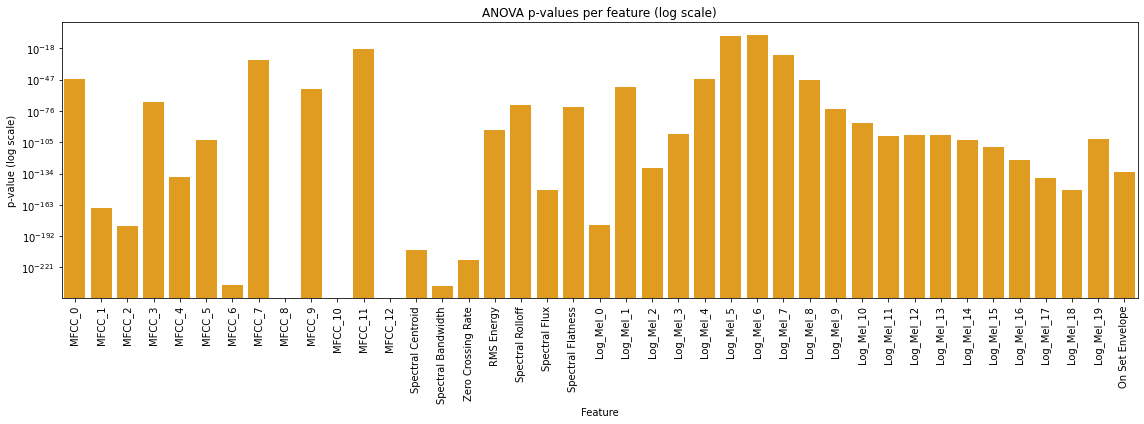

In [10]:
from utils.plots import plot_anova_stats

plot_anova_stats(training_features_mean, training_labels, FEATURE_NAMES)

### **Frame-wise feature exploration**

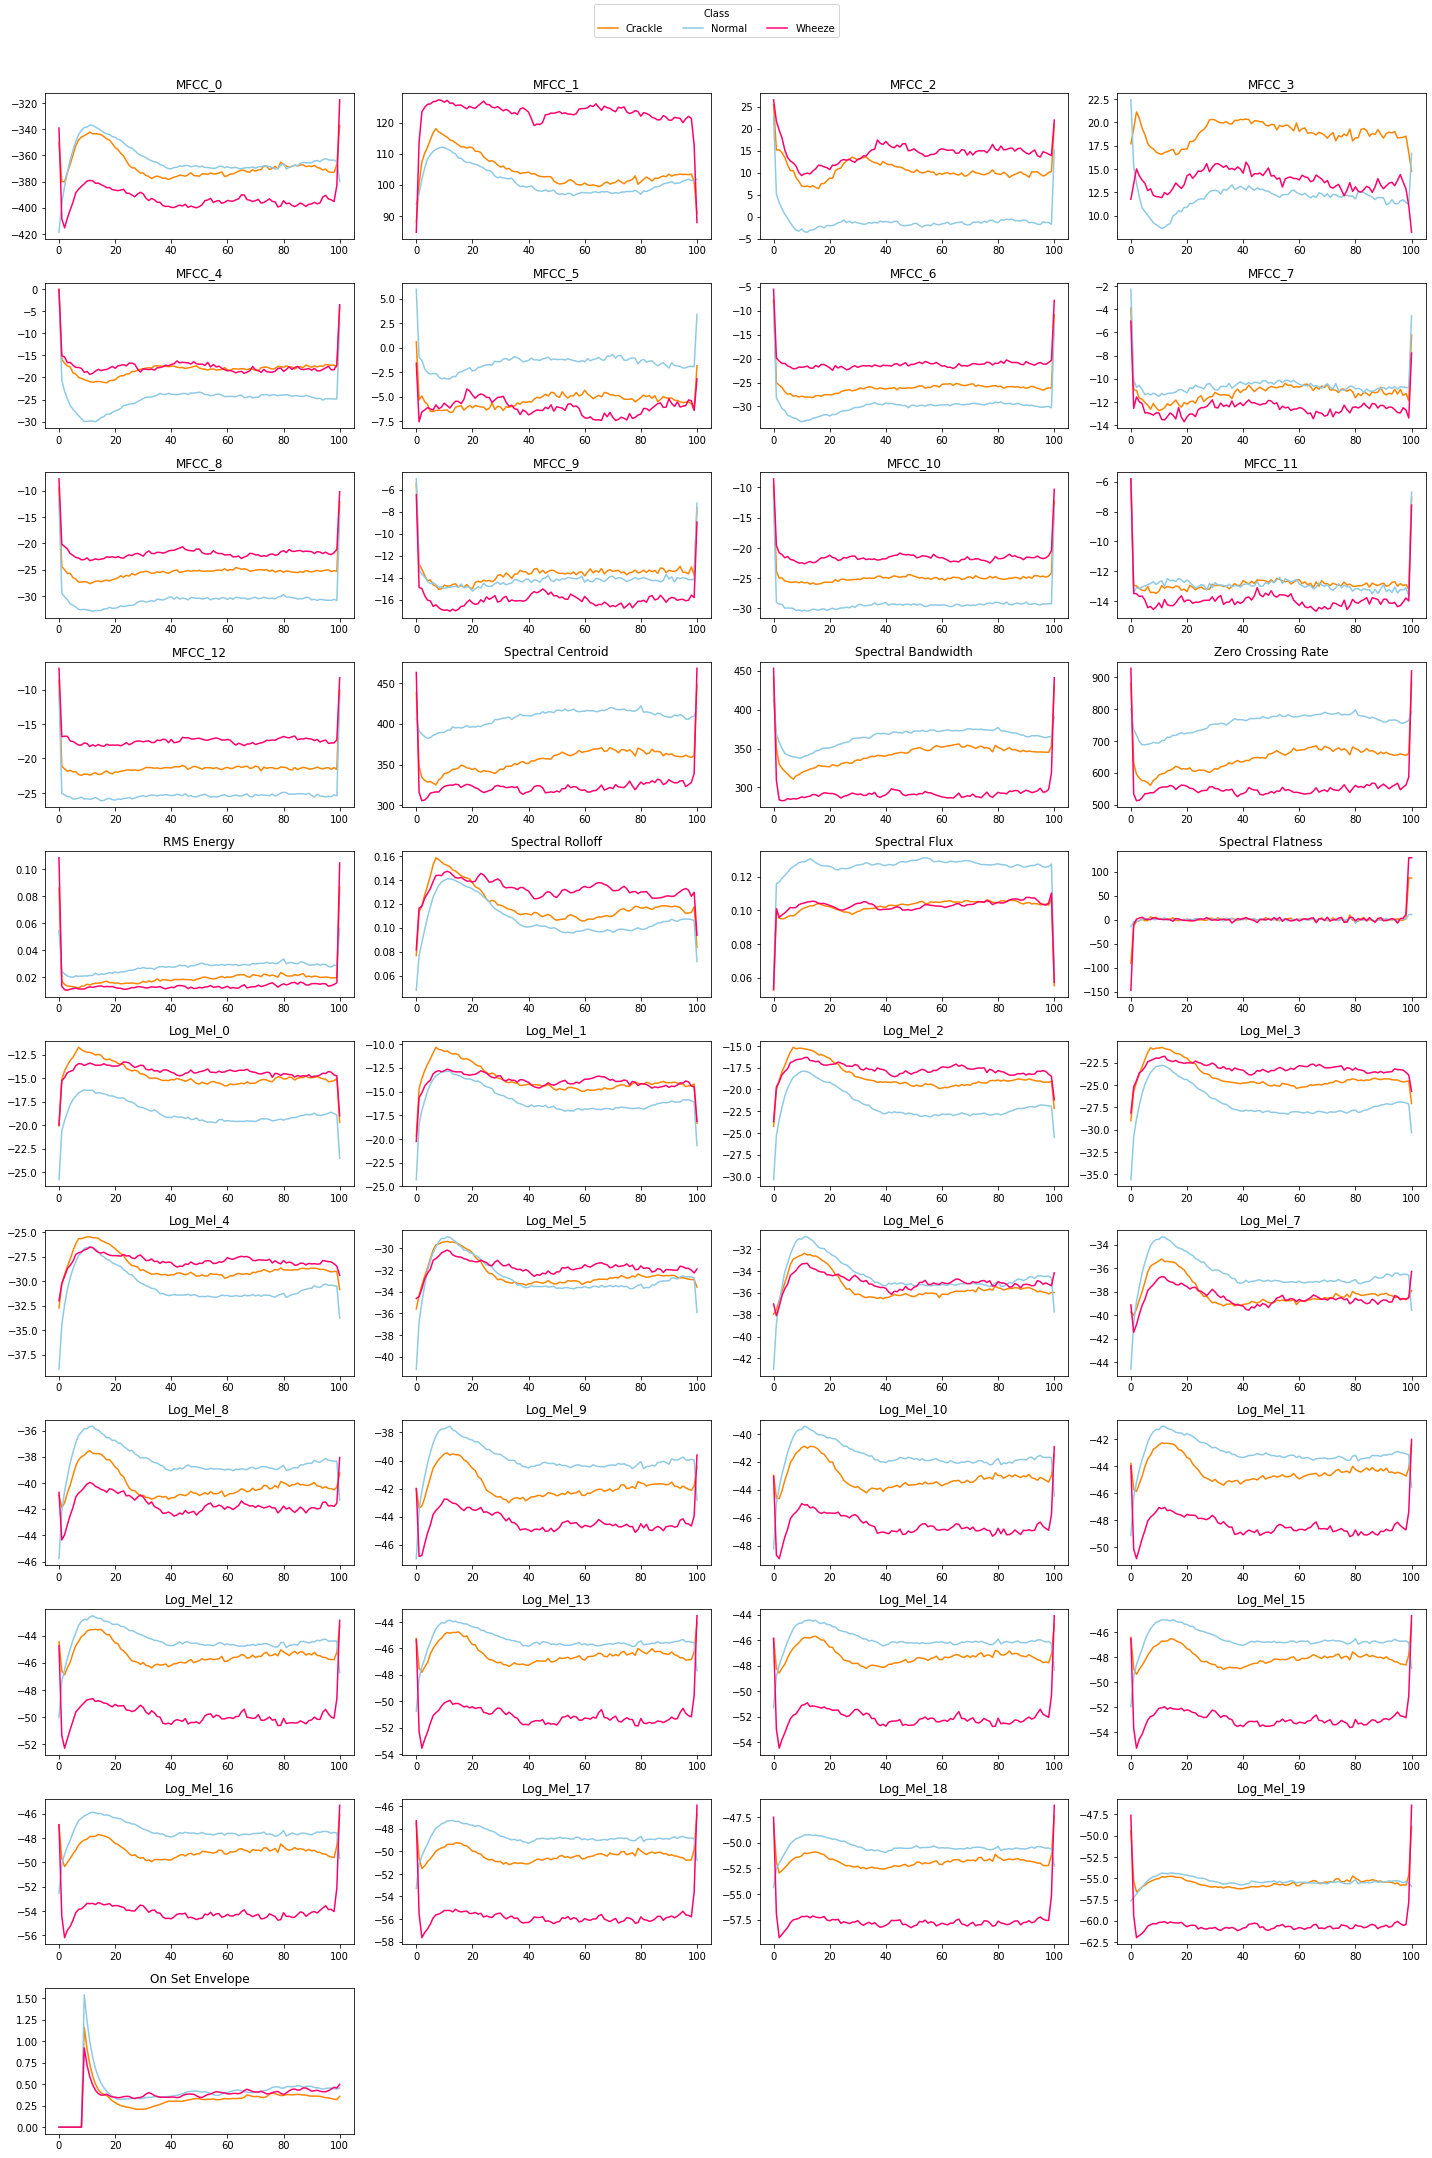

In [13]:
from utils.plots import plot_mean_feature_evolution_framewise

plot_mean_feature_evolution_framewise(training_features, training_labels, FEATURE_NAMES)

c:\Users\me\Desktop\Respiratory_Sound_Database\Respiratory_Sound_Database\venv\lib\site-packages\ipykernel_launcher.py:93: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



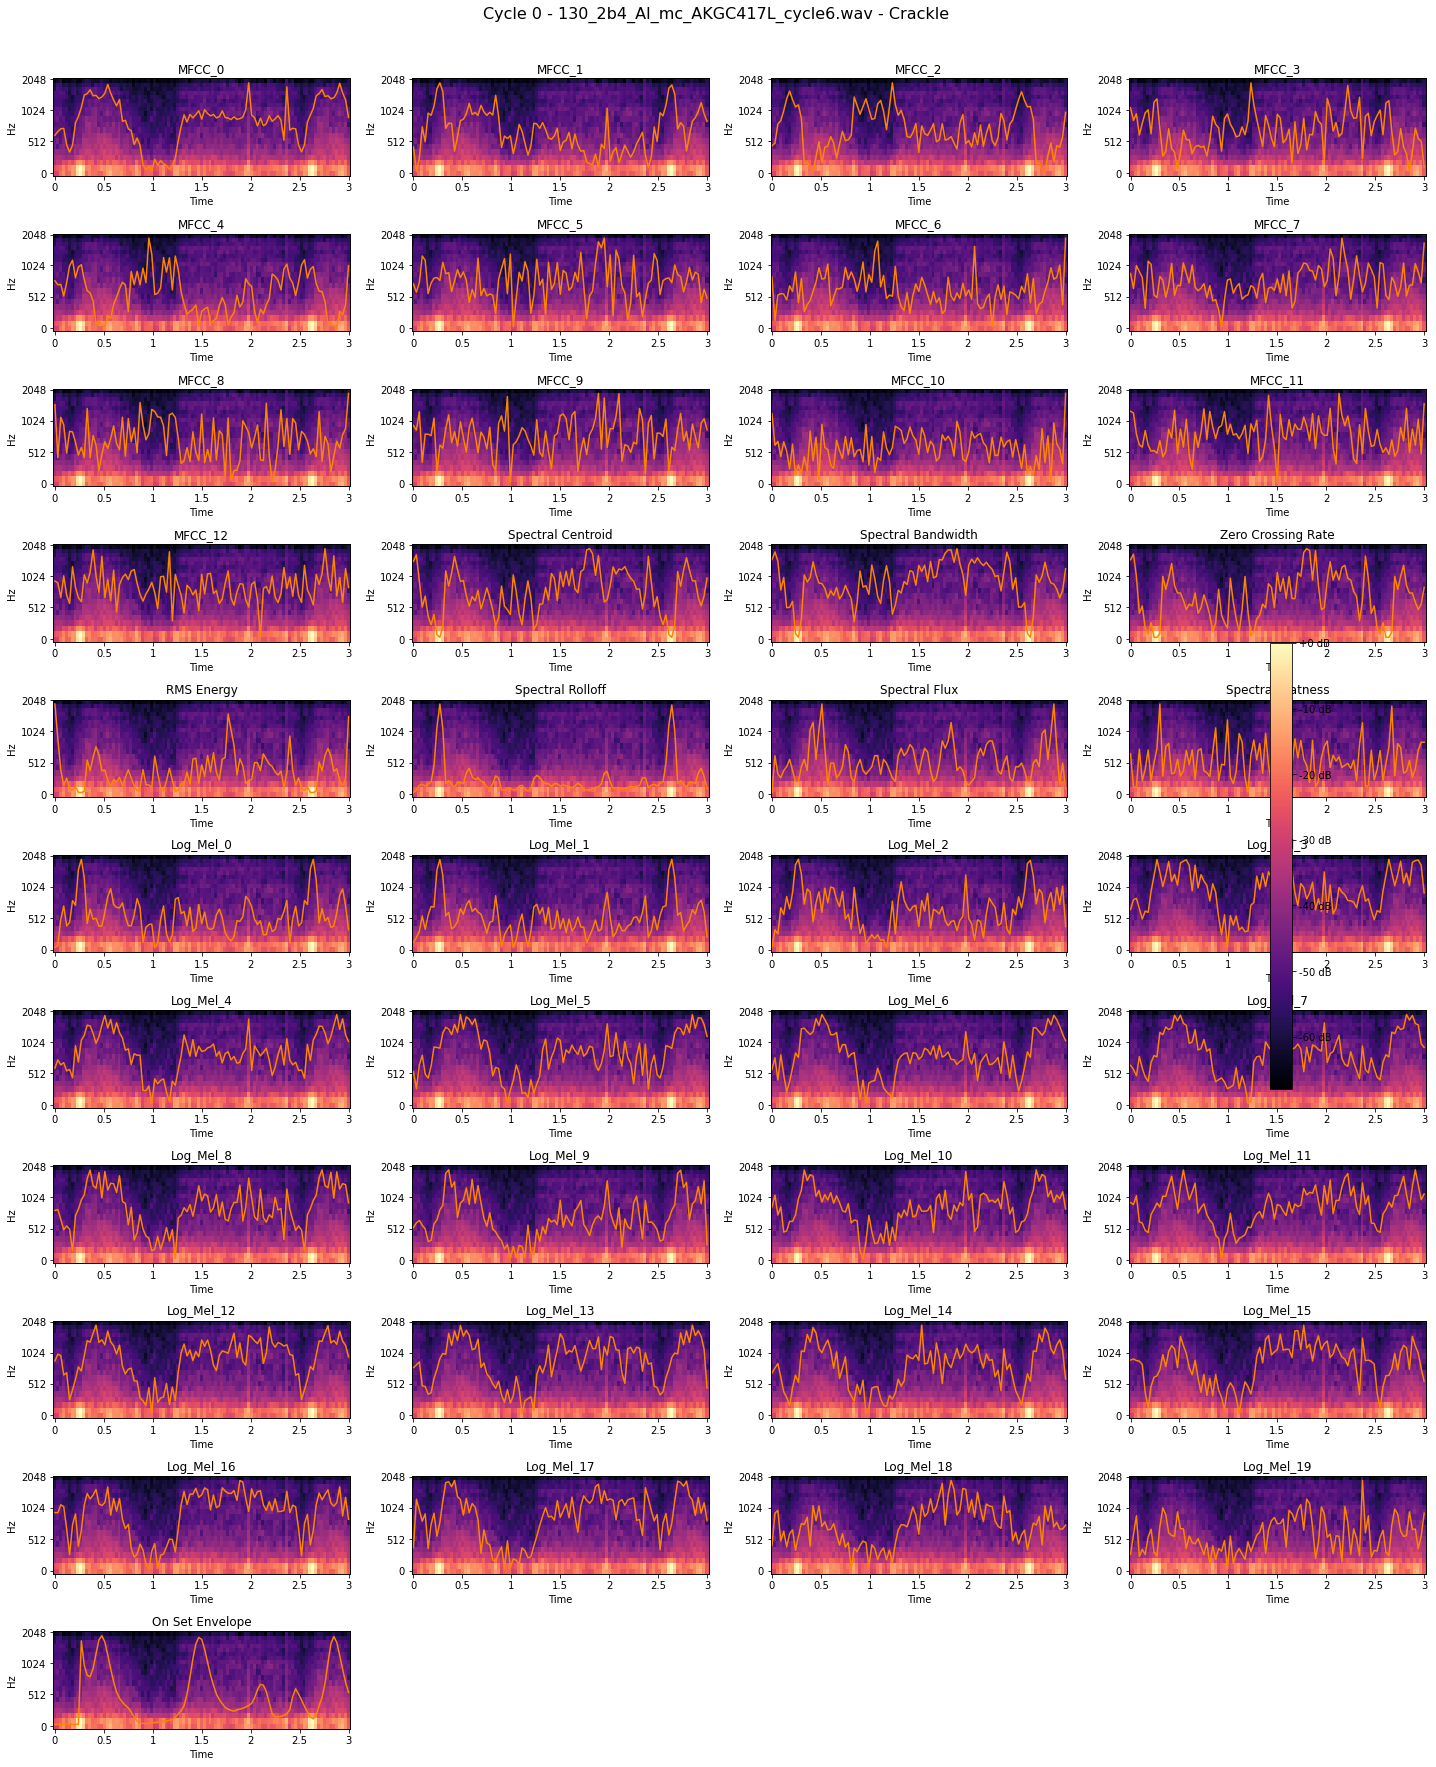

c:\Users\me\Desktop\Respiratory_Sound_Database\Respiratory_Sound_Database\venv\lib\site-packages\ipykernel_launcher.py:93: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



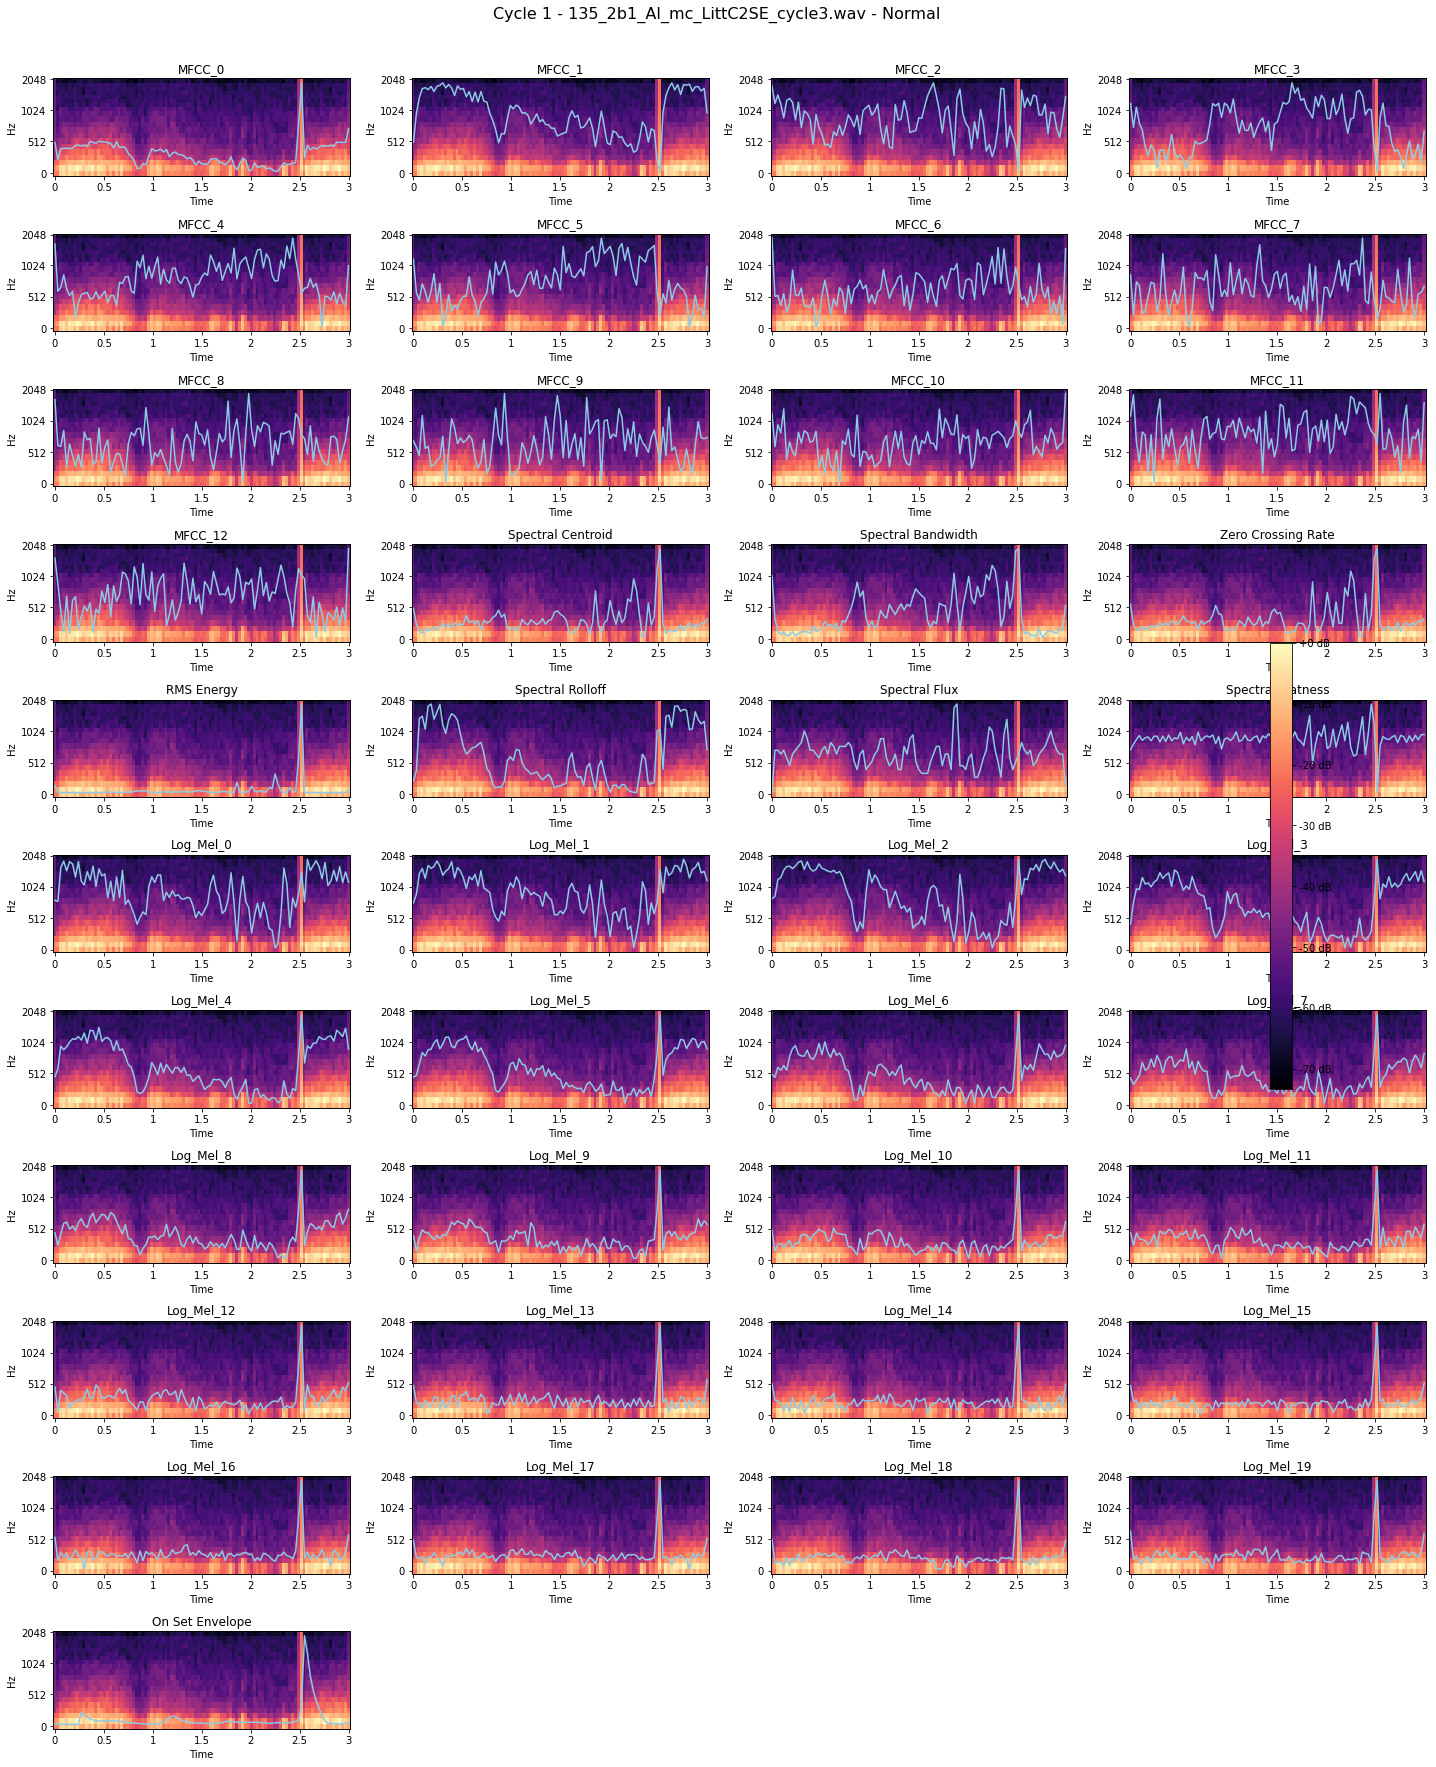

c:\Users\me\Desktop\Respiratory_Sound_Database\Respiratory_Sound_Database\venv\lib\site-packages\ipykernel_launcher.py:93: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



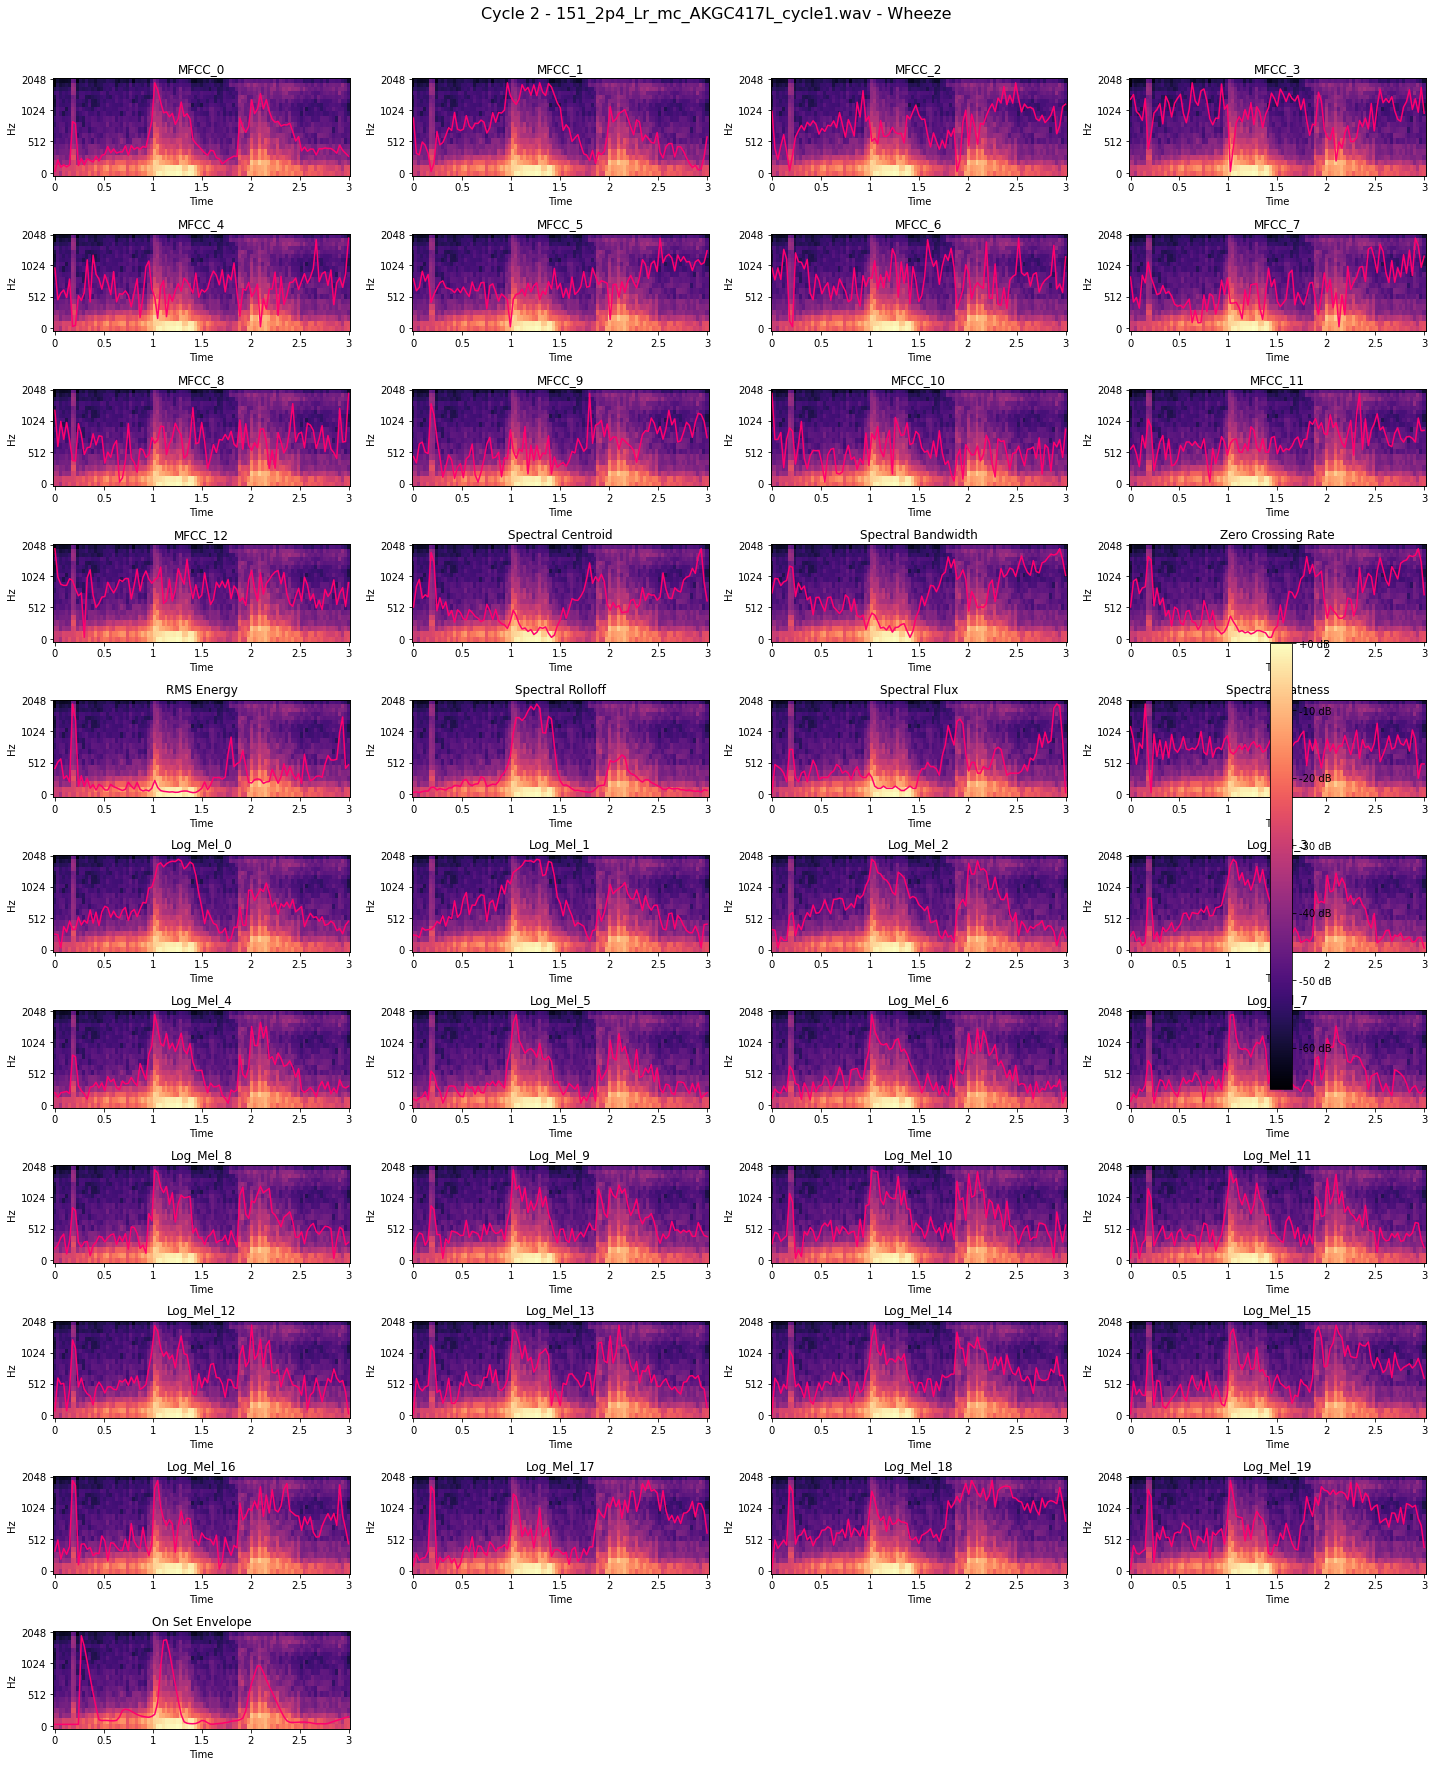

c:\Users\me\Desktop\Respiratory_Sound_Database\Respiratory_Sound_Database\venv\lib\site-packages\ipykernel_launcher.py:93: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



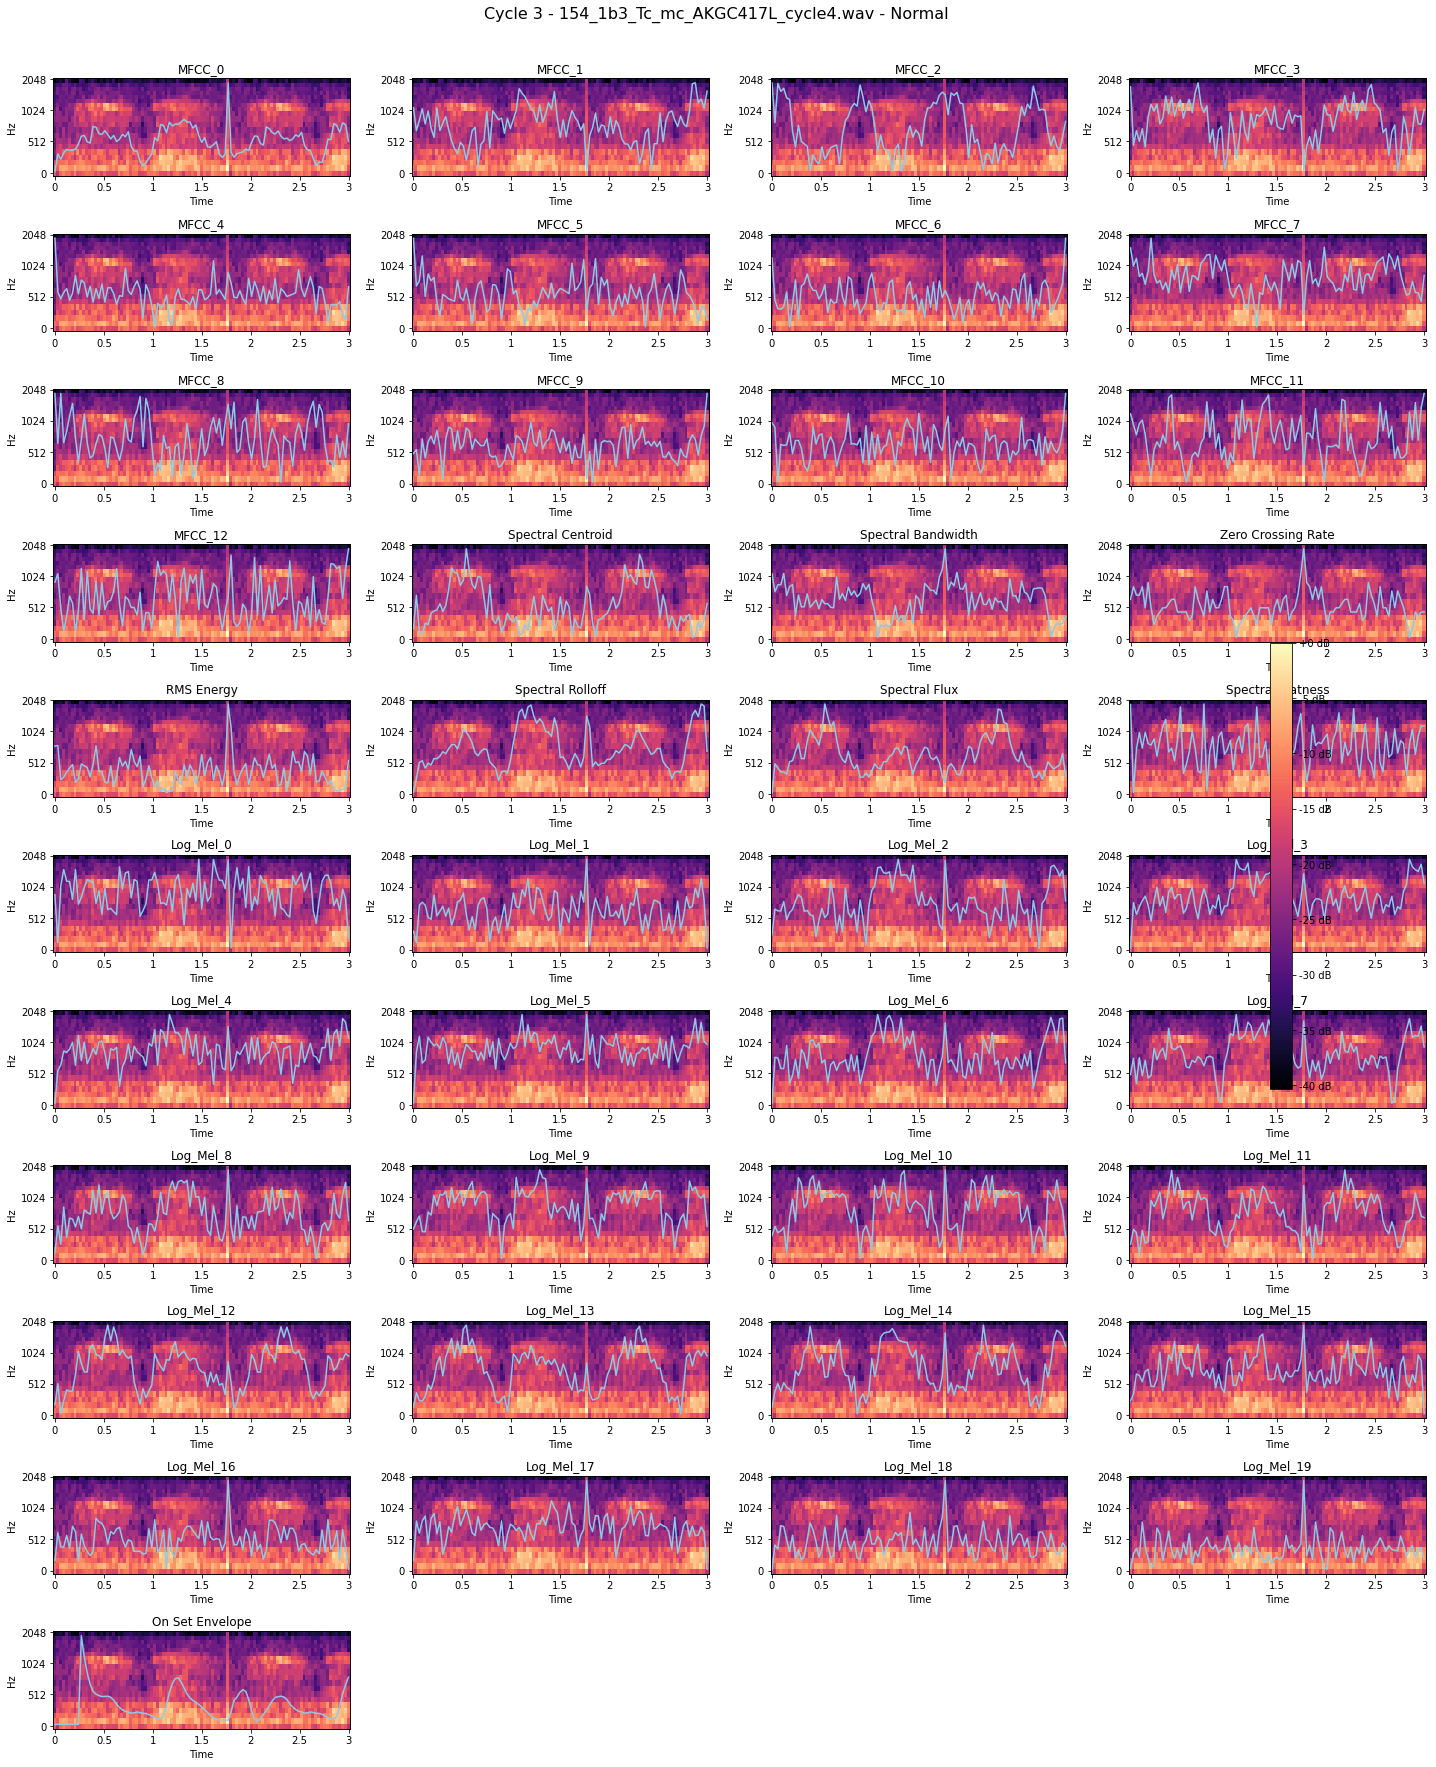

c:\Users\me\Desktop\Respiratory_Sound_Database\Respiratory_Sound_Database\venv\lib\site-packages\ipykernel_launcher.py:93: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



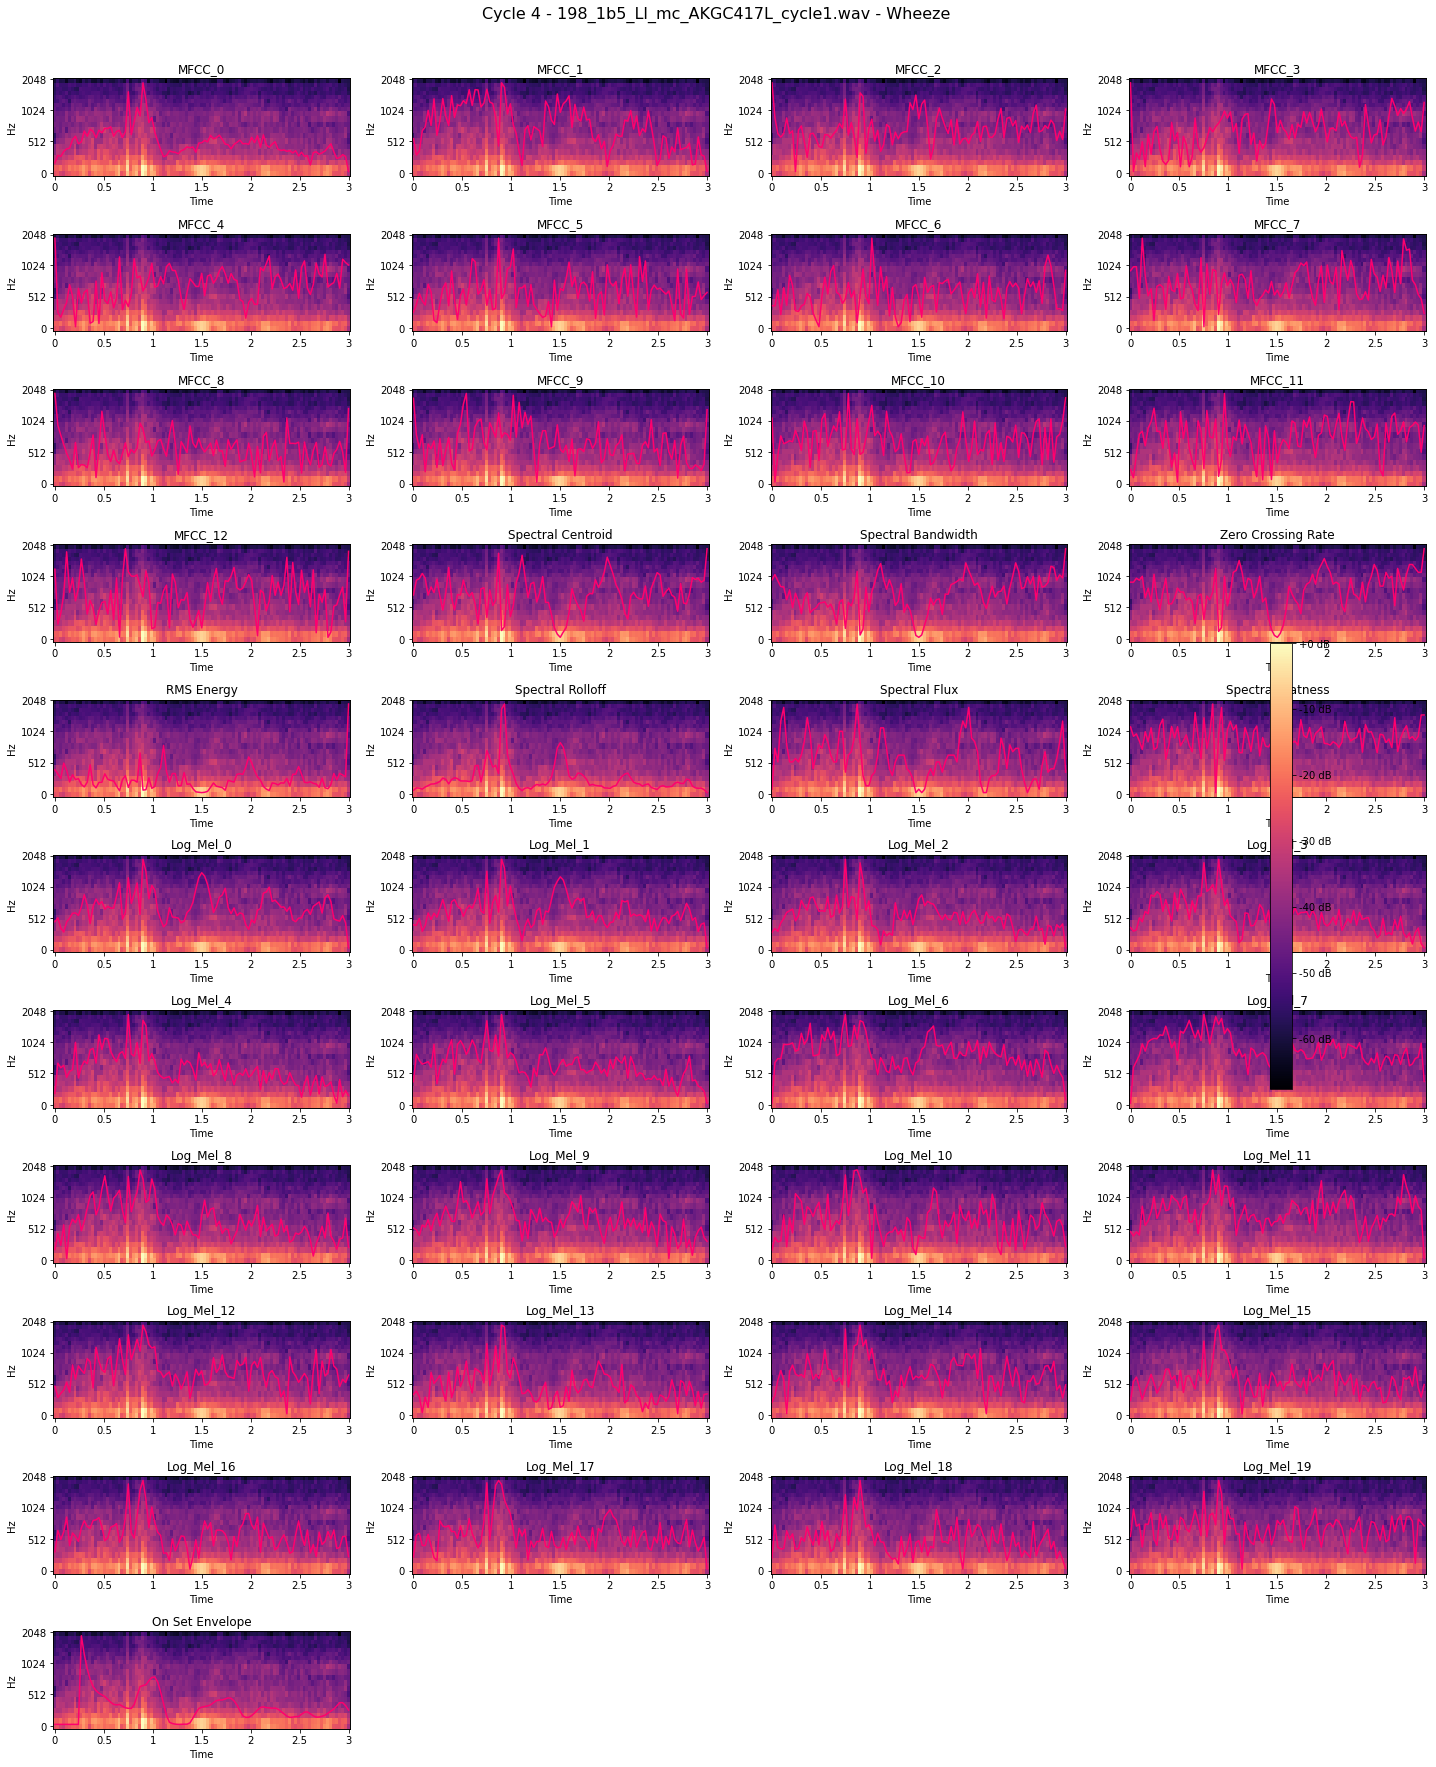

In [21]:
from utils.plots import plot_all_features_on_spectrogram_tensor

training_filenames = np.load("training_filenames.npy")

for i in range(5):  # first 5 training cycles
    plot_all_features_on_spectrogram_tensor(
        fname=training_filenames[i],
        features=training_features,  # shape: (cycles, frames, features)
        cycle_idx=i,
        label=training_labels[i],
        sampling_rate=SAMPLING_RATE,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_SIZE,
        n_mels=N_MELS,
        feature_names=FEATURE_NAMES  
    )

**Selected features after exploration**

- Spectral Centroid
- Spectral Bandwidth
- Zero Crossing Rate
- RMS Energy
- Spectral Rolloff
- Spectral Flux
- MFCC_0
- MFCC_1
- MFCC_2
- MFCC_3
- MFCC_4
- MFCC_5
- Log_Mel_0
- Log_Mel_1
- Log_Mel_2

In [ ]:
SELECTED_FEATURES = [
    "Spectral Centroid",
    "Spectral Bandwidth",
    "Zero Crossing Rate",
    "RMS Energy",
    "Spectral Rolloff",
    "Spectral Flux",
    "MFCC_0",
    "MFCC_1",
    "MFCC_2",
    "MFCC_3",
    "MFCC_4",
    "MFCC_5",
    "Log_Mel_0",
    "Log_Mel_1",
    "Log_Mel_2"
]

training_features_mean = np.load("training_features_mean.npy")
test_features_mean = np.load("test_features_mean.npy")

selected_indices = [FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

features_selected = training_features_mean[:, selected_indices]
np.save("selected_training_features_mean.npy", features_selected)
test_features_selected = test_features_mean[:, selected_indices]
np.save("selected_test_features_mean.npy", test_features_selected)

Finally, we apply **PCA / t-SNE** in 2D and 3D on the training set to determine visually whether the extracted features can help discriminate naturally the abnormal sounds into separate clusters. We also **calculate the contribution of each feature** in order to select only those features that contribute the most.

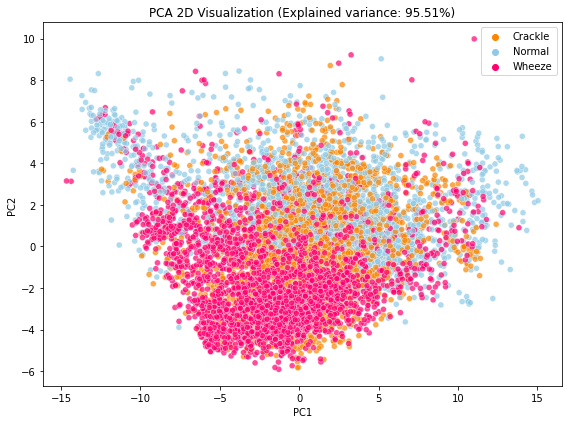

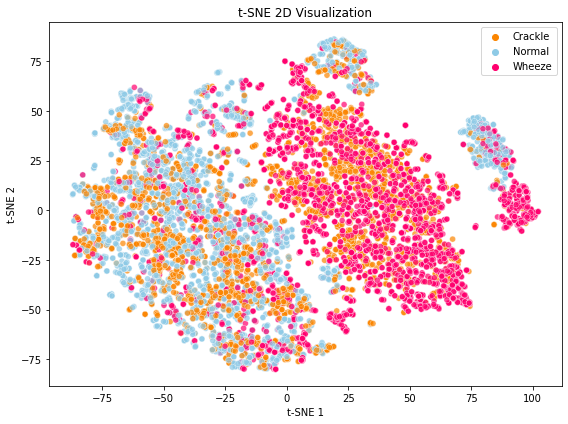

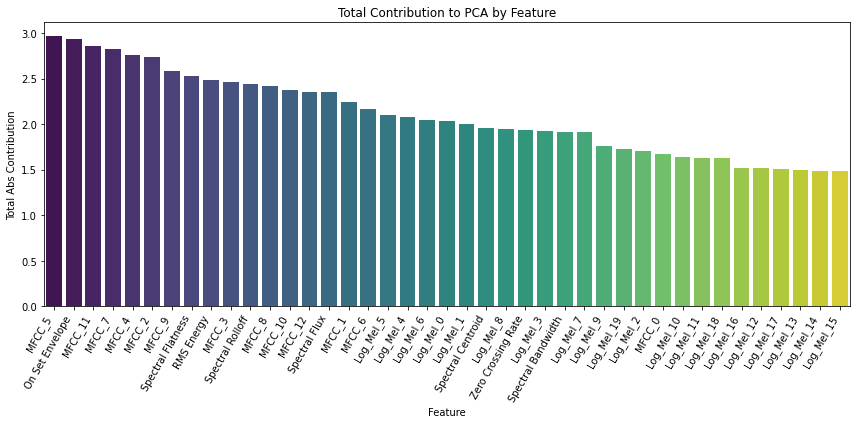

In [ ]:
from utils.plots import perform_pca_and_tsne

perform_pca_and_tsne(
    feature_matrix=training_features_mean,  # shape: (cycles, features)
    labels=training_labels,           # shape: (cycles,)
    pca_components=0.95,  # 95% variance
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES
)

**Selected features after PCA/t-SNE**

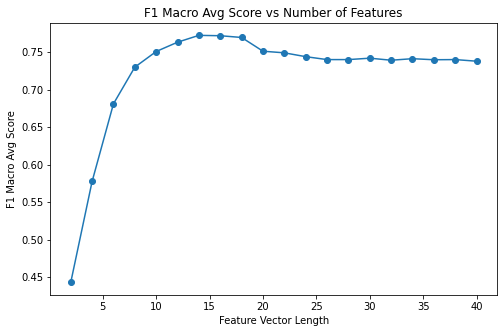

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from utils.plots import plot_feature_selection_effect

SORTED_FEATURES = [
    "MFCC_5",
    "On Set Envelope",
    "MFCC_11",
    "MFCC_7",
    "MFCC_4",
    "MFCC_2",
    "MFCC_9",
    "Spectral Flatness",
    "RMS Energy",
    "MFCC_3",
    "Spectral Rolloff",
    "MFCC_8",
    "MFCC_10",
    "Spectral Flux",
    "MFCC_1",
    "MFCC_6",
    "Log_Mel_5",
    "Log_Mel_4",
    "Log_Mel_6",
    "Log_Mel_0",
    "Log_Mel_1",
    "Spectral Centroid",
    "Log_Mel_8",
    "Zero Crossing Rate",
    "Log_Mel_3",
    "Spectral Bandwidth",
    "Log_Mel_7",
    "Log_Mel_9",
    "Log_Mel_19",
    "Log_Mel_2",
    "MFCC_0",
    "Log_Mel_10",
    "Log_Mel_11",
    "Log_Mel_18",
    "Log_Mel_16",
    "Log_Mel_12",
    "Log_Mel_17",
    "Log_Mel_13",
    "Log_Mel_14",
    "Log_Mel_15",
]

X_train = np.load("training_features_mean.npy")
y_train = np.load("training_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)

plot_feature_selection_effect(
    X_train, y_train, 
    feature_names=SORTED_FEATURES,  
    n_neighbors=3
)

In [29]:
SELECTED_FEATURES = [
    "MFCC_5",
    "On Set Envelope",
    "MFCC_11",
    "MFCC_7",
    "MFCC_4",
    "MFCC_2",
    "MFCC_9",
    "Spectral Flatness",
    "RMS Energy",
    "MFCC_3",
    "Spectral Rolloff",
    "MFCC_8",
    "MFCC_10"
]

training_features_mean = np.load("training_features_mean.npy")
test_features_mean = np.load("test_features_mean.npy")

selected_indices = [FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

training_features_selected = training_features_mean[:, selected_indices]
np.save("pca_selected_training_features_mean.npy", training_features_selected)
test_features_selected = test_features_mean[:, selected_indices]
np.save("pca_selected_test_features_mean.npy", test_features_selected)